# PPO from scratch — **V5: KL early-stop + advantage normalization**

Last of six. V4 gave you the clipped surrogate and multiple passes. V5 adds the two stabilizers
that make it *full PPO* — the algorithm as actually shipped (these are exactly spinup's defaults).

| Version | Concept |
|---|---|
| V0 | Vanilla PG |
| V1 | Learned value baseline (critic) |
| V2 | Fixed-horizon rollout buffer + bootstrapping |
| V3 | GAE-λ advantage |
| V4 | PPO-clip surrogate + multiple update passes |
| **V5 (this)** | **KL early-stop + advantage normalization** |

### Why — V4 works, what's left?
Two loose ends, both visible in your V4 run.

**1. The gradient scale swings epoch to epoch.** The policy loss averages `ratio · adv`, so the
gradient is proportional to the *absolute size* of the advantages — which changes by roughly an
order of magnitude over training (huge while the critic is bad, small once it's good). One LR
cannot fit both regimes; your V4 run sitting at 0–1 goals for three epochs before catching on is
what that looks like.

**2. The pass count is a guess.** You set `TRAIN_PI_ITERS=10` and scaled the LR down by it — a
good instinct: spread the learning over gentle passes. But 10 is only right *on average*. On a
batch where the policy barely moves you could safely take 80 passes; on one where it lurches, 10
is already too many. The clip *flattens* the objective outside the trust region, but it doesn't
*stop* the optimizer. The thing you actually care about is: **how far has the new policy drifted
from the one that collected this data?** Measure that directly, and stop when a budget is spent.
The pass count stops being a hyperparameter; the drift budget is.

### What you build in V5 (three TODOs)
1. `normalize_advantages` — standardize a batch of advantages.
2. `compute_approx_kl` — measure the policy's drift from the frozen rollout data.
3. `train_one_epoch` — your V4, with normalization applied once per batch, and the update loop
   turned into "up to `TRAIN_PI_ITERS` passes, stop early when the drift budget is spent".

### ✅ Done-when
- Both **unit tests** (given) pass.
- The **`pi_iters` column** in the training print is doing real work: pinned low (often 1–4)
  while the policy is moving fast, opening up — sometimes to the 80 ceiling — once it settles.
  If it sits at the ceiling *every* epoch, your KL stop never fires; if the training print looks
  like V4 exploded, your normalization probably isn't reaching the loss.
- Training return in the −80s/−90s by epoch 14 with `goals` ≥ ~40. One honest caveat: on an
  unlucky seed Acrobot gives *zero* learning signal until the first goal, so the −500 plateau can
  last many epochs (my seed-1 reference sat there for 10, then hit 40 goals five epochs later).
  Judge the slope of the take-off, not the epoch it happens.
- Greedy eval mean in the −80s or better (reference seeds: −82 ± 23, −77 ± 10). This is the
  finale — line up mean AND ± across V0→V5.

> Kernel: `ppo`. Policy (incl. your `sample_with_logprob`), critic, GAE buffer, PPO-clip loss,
> and the eval harness are your V4 code, unchanged.

## Imports & configuration *(given — V5 adds the stabilizer knobs)*

In [22]:
import numpy as np
import torch
import torch.nn as nn
from torch.optim import Adam
from torch.distributions.categorical import Categorical
import torch.nn.functional as F
import gymnasium as gym
from gymnasium.spaces import Discrete, Box

ENV_NAME   = "Acrobot-v1"
SEED       = 0
HIDDEN     = [64, 64]
EPOCHS     = 15
GAMMA      = 0.99

STEPS_PER_EPOCH = 4000     # fixed transitions collected per epoch
LAM             = 0.95     # GAE-lambda
CLIP_RATIO      = 0.2      # PPO clip epsilon

# ---- NEW in V5 --------------------------------------------------------------
PI_LR           = 4e-3     # per-pass policy LR. Your V4 ran Adam at LR/TRAIN_PI_ITERS -- same idea,
                           # made explicit, because the KL stop makes the pass count variable.
TRAIN_PI_ITERS  = 80       # now a CEILING on passes per rollout -- the KL stop is the real brake
TARGET_KL       = 0.01     # drift budget: stop the passes once approx KL exceeds ~1.5x this

VALUE_LR        = 1e-2
VALUE_FIT_ITERS = 80

print("gymnasium", gym.__version__, "| torch", torch.__version__)

gymnasium 1.3.0 | torch 2.13.0+cpu


## Policy, critic, losses, helpers *(given — your V4 code, unchanged)*

In [2]:
class MyPolicy(nn.Module):
    def __init__(self, input_size: int, output_size: int) -> None:
        super().__init__()
        sizes = [input_size] + HIDDEN + [output_size]
        layers = []
        for in_sz, out_sz in zip(sizes, sizes[1:]):
            layers.append(nn.Linear(in_sz, out_sz))
            layers.append(nn.Tanh())
        layers = layers[:-1]
        self.linear_layers = nn.Sequential(*layers)

    def forward(self, x: torch.Tensor) -> Categorical:
        return Categorical(logits=self.linear_layers(x))

    def greedy(self, x: torch.Tensor) -> torch.Tensor:
        return self.linear_layers(x).argmax()

    def sample(self, x: torch.Tensor) -> torch.Tensor:
        return self(x).sample()
    
    def sample_with_logprob(self, x: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor]:
        distribution = self.forward(x)
        action = distribution.sample()
        logprob = distribution.log_prob(action)
        return action, logprob


class MyCritic(nn.Module):
    def __init__(self, input_size: int) -> None:
        super().__init__()
        sizes = [input_size] + HIDDEN
        layers = []
        for in_sz, out_sz in zip(sizes, sizes[1:]):
            layers.append(nn.Linear(in_sz, out_sz))
            layers.append(nn.Tanh())
        layers.append(nn.Linear(HIDDEN[-1], 1))
        self.linear_layers = nn.Sequential(*layers)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.linear_layers(x).squeeze(-1)


def reward_to_go(rews: list[float], gamma: float = GAMMA) -> list[float]:
    """Discounted reward-to-go for a sequence. Handy for the buffer: append a bootstrap
    value to the rewards, take reward_to_go, and drop the last element."""
    n = len(rews)
    gamma_pows = gamma ** np.arange(n)
    cum_rews = []
    for i in range(n):
        left = n - i
        cr = (np.asarray(rews[i:]) * gamma_pows[:left]).sum()
        cum_rews.append(cr)
    return cum_rews


def compute_loss(policy: MyPolicy, obs: torch.Tensor, act: torch.Tensor,
                 weights: torch.Tensor) -> torch.Tensor:
    logp = policy(obs).log_prob(act)
    return -((logp) * weights).mean()


def compute_value_loss(critic: MyCritic, obs: torch.Tensor, returns: torch.Tensor) -> torch.Tensor:
    return F.mse_loss(critic(obs), returns)


def make_env(env_name: str = ENV_NAME, render_mode: str | None = None) -> gym.Env:
    return gym.make(env_name, render_mode=render_mode)


def set_seed(env: gym.Env, seed: int = SEED) -> None:
    torch.manual_seed(seed)
    np.random.seed(seed)
    env.reset(seed=seed)
    env.action_space.seed(seed)


_e = make_env()
OBS_DIM = _e.observation_space.shape[0]
N_ACTS  = _e.action_space.n
MAX_STEPS = _e.spec.max_episode_steps
print(f"{ENV_NAME}: obs_dim={OBS_DIM}, n_acts={N_ACTS}, max_steps={MAX_STEPS}")
_e.close()


Acrobot-v1: obs_dim=6, n_acts=3, max_steps=500


## GAE + buffer + PPO-clip loss *(given — your V4 code, unchanged)*

In [3]:
def gae(rewards: list[float], values: list[float], final_value: float,
        lamb: float, gamma: float) -> list[float]:
    V = values + [final_value]
    n = len(rewards)
    deltas = []
    for t in range(n):
        deltas.append( rewards[t] + gamma*V[t+1] - V[t])
    deltas = np.array(deltas)
    adventages = np.zeros(n, dtype=np.float32)
    adventages[-1] = deltas[-1]
    for t in reversed(range(n-1)):
        adventages[t] =  deltas[t] + gamma * lamb * adventages[t+1]
    return adventages.tolist()

    


In [4]:
class RolloutBuffer:
    # GIVEN in V5: your V4 buffer, unchanged. get_data() -> (obs, act, ret, adv, logp).
    def __init__(self, max_steps: int) -> None:
        self.obs_buffer = []
        self.actions_buffer = []
        self.rewards_buffer = []
        self.adventage_buffer = []
        self.trajectory_raw_rewards = []
        self.trajectory_raw_values = []
        self.logp_buffer = []
        self.max_steps = max_steps

    def append(self, obs: torch.Tensor, action: int, reward: float, val: float, logp: float) -> None:
        self.obs_buffer.append(obs)
        self.actions_buffer.append(action)
        self.trajectory_raw_rewards.append(reward)
        self.trajectory_raw_values.append(val)
        self.logp_buffer.append(logp)
    
    def finish_trajectory(self, terminal_value: float) -> None:
        if len(self.trajectory_raw_rewards) > 0:
            accumulated_rewards = reward_to_go(self.trajectory_raw_rewards + [terminal_value])
            adventages = gae(self.trajectory_raw_rewards, self.trajectory_raw_values, terminal_value, LAM, GAMMA)
            self.rewards_buffer += accumulated_rewards[:-1]
            self.adventage_buffer += adventages
            self.trajectory_raw_rewards = []
            self.trajectory_raw_values=[]

    def full(self) -> bool:
        return len(self.obs_buffer) >= self.max_steps
    
    def get_data(self) -> tuple[torch.Tensor, torch.Tensor, torch.Tensor, torch.Tensor, torch.Tensor]:
        obs_batch_tensor = torch.stack(self.obs_buffer)
        actions_tensor = torch.tensor(self.actions_buffer)
        rewards_tensor = torch.tensor(self.rewards_buffer, dtype=torch.float32)
        adv_tensor = torch.tensor(self.adventage_buffer, dtype=torch.float32)
        logp_tensor = torch.tensor(self.logp_buffer, dtype=torch.float32)
        return obs_batch_tensor, actions_tensor, rewards_tensor, adv_tensor, logp_tensor
    


## 1. Advantage normalization *(you implement)*

The advantage's job in the loss is purely **relative**: within one batch it says which actions
were better than expected and by how much, compared to the others. Its **absolute scale** carries
no extra information for the policy — you showed in V1 that shifting all weights by a constant
doesn't change the expected gradient direction, and a global rescale is indistinguishable from
changing the LR. So the scale is a free parameter — and left free, it drifts wildly over training
and drags your effective LR around with it.

**Standardize each batch**: shift and rescale the advantages so the batch has mean 0 and standard
deviation 1. Every epoch's update is then the same size, and one `PI_LR` fits all fifteen. Two
details worth thinking about: make it safe for a batch where all advantages are equal (spread 0),
and treat it as a *policy-side* transform only — the critic still regresses on the raw returns,
exactly the λ-style separation you caught in V3.

In [5]:
def normalize_advantages(adv: torch.Tensor) -> torch.Tensor:
    # TODO (V5): standardize the batch -- mean 0, spread 1. Guard the division for a
    # zero-spread batch. Return a new tensor; don't mutate the input.
    adv = adv - adv.mean()
    if adv.std() > 0:
        adv /= adv.std()
    return adv

### 🔬 Unit test — normalization *(given)*

In [6]:
def _test_adv_norm() -> None:
    torch.manual_seed(1)
    raw = torch.randn(1000) * 7.3 + 42.0        # wild scale and offset, like early-training advantages
    out = normalize_advantages(raw)
    assert isinstance(out, torch.Tensor) and out.shape == raw.shape
    m, s = out.mean().item(), out.std().item()
    assert abs(m) < 1e-4,      f"mean should be ~0, got {m:+.5f}"
    assert abs(s - 1.0) < 0.05, f"std should be ~1, got {s:.3f}"
    assert torch.equal(out.argsort(), raw.argsort()), "must preserve the ordering of the batch"
    corr = torch.corrcoef(torch.stack([raw, out]))[0, 1].item()
    assert corr > 0.9999, "must be a pure shift-and-rescale (affine) of the input"
    assert raw.mean().item() > 40, "input was mutated -- normalize a copy, not in place"
    print(f"adv-norm OK: mean {m:+.5f}  std {s:.3f}  (raw was mean {raw.mean():.1f}, std {raw.std():.1f})")

_test_adv_norm()

adv-norm OK: mean +0.00000  std 1.000  (raw was mean 42.1, std 7.5)


In [17]:
def compute_ppo_loss(current_logp: torch.Tensor,
                     adv: torch.Tensor, logp_old: torch.Tensor, clip_ratio: float) -> torch.Tensor:
    # GIVEN in V5: your V4 clipped surrogate, unchanged.    
    ratio = torch.exp(current_logp - logp_old)
    clipped_ratio = torch.clip(ratio, 1-clip_ratio, 1+clip_ratio)
    loss = - torch.min(ratio * adv, clipped_ratio * adv).mean()
    return loss


## 2. Approximate KL — measuring the drift *(you implement)*

The quantity we budget is the KL divergence from the rollout policy to the current one,

$$D_{KL}(\pi_{old} \,\|\, \pi_{new}) = \mathbb{E}_{a \sim \pi_{old}}\big[\log \pi_{old}(a|s) - \log \pi_{new}(a|s)\big]$$

and your rollout batch is *exactly* a sample from `π_old` — so averaging
`logp_old − logp_new` over the batch estimates it directly. You already have both ingredients:
`logp_old` sits frozen in the buffer, and `logp_new` is one policy forward away.

Three things to get right, all conceptual:
- **The direction matters.** old minus new, in expectation over *old*-policy actions. Flip it and
  you're estimating a different divergence (the unit test will catch you).
- **It's a measurement, not a loss** — no gradients should flow through it.
- It's a *sample estimate*, so it's noisy and can even dip slightly negative on a quiet batch.
  That noise is why the stopping rule (next section) budgets ~1.5× `TARGET_KL`, not `TARGET_KL`
  exactly — the same slack spinup uses.

In [8]:
def compute_approx_kl(current_logp: torch.Tensor, logp_old: torch.Tensor) -> float:
    return (logp_old - current_logp).mean().item()

### 🔬 Unit test — approx KL *(given)*

In [9]:
def _test_approx_kl() -> None:
    logp_old = torch.tensor([-1.0, -1.0, -1.0, -1.0])
    logp_new = torch.tensor([-1.3, -0.9, -1.1, -1.0])   # a policy that drifted


    kl = compute_approx_kl(logp_new, logp_old)
    assert isinstance(kl, float), f"should return a plain float, got {type(kl).__name__}"
    assert abs(kl - 0.075) < 1e-6, (
        f"expected 0.075, got {kl:+.4f}"
        + ("  <- sign flipped: the expectation is over OLD-policy samples" if abs(kl + 0.075) < 1e-6 else ""))

    kl0 = compute_approx_kl(logp_new, logp_new.clone())
    assert abs(kl0) < 1e-8, f"identical policies must measure zero drift, got {kl0:+.6f}"
    print(f"approx-KL OK: drifted batch {kl:.4f}, identical policies {kl0:.4f}")

_test_approx_kl()

approx-KL OK: drifted batch 0.0750, identical policies 0.0000


## 3. Rollout + KL-stopped update *(you implement)*

Your V4 `train_one_epoch`, with the two stabilizers wired in. The rollout and the critic fit
don't change at all. What changes:

- The advantages get **normalized once per batch** — after they leave the buffer, before the
  first policy pass. (Policy side only.)
- The policy loop becomes **"up to `TRAIN_PI_ITERS` passes"**: after each pass, measure the drift
  against the *frozen* `logp_old`, and stop as soon as it exceeds ~1.5× `TARGET_KL`. The clip
  guards each step; the KL stop decides how many steps this particular batch deserves.
- Count the passes that actually ran and return the count — the driver prints it as `pi_iters`,
  and watching it move around is most of the fun of V5.

One thing to notice while you write it: with normalized advantages, `PI_LR` finally means the same
thing every epoch — which is what makes a fixed drift budget coherent in the first place. The two
stabilizers aren't independent fixes; they only work as a pair.

In [24]:
def train_one_epoch(env: gym.Env, policy_net: MyPolicy, critic_net: MyCritic,
                    policy_optimizer: Adam, critic_optimizer: Adam,
                    ) -> tuple[list[float], list[int], float, int, int]:
    # TODO (V5): your V4 train_one_epoch + the two edits described above.
    # Return (batch_rets, batch_lens, v_loss, n_goals, n_pi_iters).
    buffer = RolloutBuffer(STEPS_PER_EPOCH)
    n_goals = 0
    batch_lens =[]
    batch_rets = []
    while not buffer.full():
        obs = torch.tensor(env.reset()[0], dtype = torch.float32)
        done = False
        while not done:
            with torch.no_grad():
                action, log_p =policy_net.sample_with_logprob(obs)
                action, log_p = int(action), log_p.item()
                value = critic_net(obs).item()
            next_obs, rew, terminated, truncated, info = env.step(action)
            done = terminated or truncated
            timeout = truncated and not terminated
            buffer.append(obs,action, rew, value, log_p)
            obs = torch.tensor(next_obs, dtype = torch.float32)

            if buffer.full() and not done:
                done, timeout = True, True
            if done:
                if not buffer.full():
                    batch_lens.append(len(buffer.trajectory_raw_rewards))
                    batch_rets.append(sum(buffer.trajectory_raw_rewards))
                if not timeout:
                    final_v = 0
                    n_goals +=1
                else:
                    with torch.no_grad():
                        final_v = critic_net(obs).item()
                buffer.finish_trajectory(final_v)
    obs_batch_tensor, actions_tensor, rewards_tensor, adventage_tensor, logp_old_tensor = buffer.get_data()
    for _ in range(VALUE_FIT_ITERS):
        critic_optimizer.zero_grad()
        critic_loss = compute_value_loss(critic_net, obs_batch_tensor, rewards_tensor)
        critic_loss.backward()
        critic_optimizer.step()
    
    p_iters = 0
    adventage_tensor = normalize_advantages(adventage_tensor)
    kl_broke = False
    for p_iters in range(TRAIN_PI_ITERS):
        policy_optimizer.zero_grad()
        current_logp = policy_net(obs_batch_tensor).log_prob(actions_tensor)
        kl = compute_approx_kl(current_logp.detach() ,logp_old_tensor)
        if kl >= 1.5 * TARGET_KL:
            kl_broke = True
            break
        loss = compute_ppo_loss(current_logp, adventage_tensor, logp_old_tensor, CLIP_RATIO)
        loss.backward()
        policy_optimizer.step()
        
    return batch_rets, batch_lens, critic_loss.item(), n_goals, p_iters if kl_broke else p_iters + 1


## Evaluation & recording harness *(given — your V4 code, unchanged)*

In [25]:
def greedy_action(obs: np.ndarray) -> torch.Tensor:
    with torch.no_grad():
        return policy_net.greedy(torch.tensor(obs, dtype=torch.float32))


def evaluate(env_name: str = ENV_NAME, n_episodes: int = 10, seed: int = 1000) -> tuple[float, float]:
    """Average greedy return over n_episodes. Our comparison metric."""
    env = make_env(env_name)
    rets = []
    for i in range(n_episodes):
        obs, _ = env.reset(seed=seed + i)
        done, ep_ret = False, 0.0
        while not done:
            obs, r, terminated, truncated, _ = env.step(greedy_action(obs))
            done = terminated or truncated
            ep_ret += r
        rets.append(ep_ret)
    env.close()
    return float(np.mean(rets)), float(np.std(rets))


def record_gif(out_path: str, env_name: str = ENV_NAME, episodes: int = 3, fps: int = 15) -> None:
    """Greedy rollout -> GIF saved to disk AND shown inline (animated) in the notebook."""
    try:
        import imageio
        env = make_env(env_name, render_mode="rgb_array")
        frames = []
        for _ in range(episodes):
            obs, done = env.reset()[0], False
            while not done:
                frames.append(env.render())
                obs, _, terminated, truncated, _ = env.step(greedy_action(obs))
                done = terminated or truncated
        env.close()
        imageio.mimsave(out_path, frames, fps=fps)
        print(f"saved {len(frames)} frames -> {out_path}")
        from IPython.display import Image, display
        display(Image(filename=out_path))
    except Exception as ex:
        print("record_gif skipped (likely headless):", repr(ex))


## Train *(given — drives your code)*

In [26]:
env = make_env()
set_seed(env, SEED)

policy_net = MyPolicy(OBS_DIM, N_ACTS)
policy_optimizer = Adam(policy_net.parameters(), lr=PI_LR)

critic_net = MyCritic(OBS_DIM)
critic_optimizer = Adam(critic_net.parameters(), lr=VALUE_LR)

for epoch in range(EPOCHS):
    batch_rets, batch_lens, v_loss, n_goals, n_pi_iters = train_one_epoch(
        env, policy_net, critic_net, policy_optimizer, critic_optimizer)
    avg_ret = np.mean(batch_rets) if len(batch_rets) else float("nan")
    avg_len = np.mean(batch_lens) if len(batch_lens) else float("nan")
    print("epoch %3d \t return %8.1f \t ep_len %6.1f \t v_loss %8.2f \t goals %3d \t pi_iters %3d" %
          (epoch, avg_ret, avg_len, v_loss, n_goals, n_pi_iters))
env.close()

epoch   0 	 return   -500.0 	 ep_len  500.0 	 v_loss  1570.97 	 goals   0 	 pi_iters   1
epoch   1 	 return   -500.0 	 ep_len  500.0 	 v_loss   275.65 	 goals   0 	 pi_iters  80
epoch   2 	 return   -486.5 	 ep_len  486.6 	 v_loss    91.33 	 goals   1 	 pi_iters   6
epoch   3 	 return   -495.8 	 ep_len  496.0 	 v_loss   113.99 	 goals   2 	 pi_iters   4
epoch   4 	 return   -308.8 	 ep_len  309.8 	 v_loss   137.74 	 goals  11 	 pi_iters   3
epoch   5 	 return   -226.3 	 ep_len  227.2 	 v_loss   239.50 	 goals  16 	 pi_iters   3
epoch   6 	 return   -164.9 	 ep_len  165.9 	 v_loss    93.87 	 goals  24 	 pi_iters   2
epoch   7 	 return   -135.2 	 ep_len  136.2 	 v_loss   149.77 	 goals  28 	 pi_iters   2
epoch   8 	 return   -107.6 	 ep_len  108.6 	 v_loss    72.38 	 goals  36 	 pi_iters   2
epoch   9 	 return   -101.3 	 ep_len  102.3 	 v_loss   157.47 	 goals  39 	 pi_iters   3
epoch  10 	 return    -95.5 	 ep_len   96.5 	 v_loss   265.13 	 goals  41 	 pi_iters   5
epoch  11 	 return   

## ✅ Verify V5 *(given)*

The diagnostic below rolls out one fresh batch and shows the advantages **before and after** your
normalization — the raw spread is whatever the task hands you; the normalized one should be
mean ≈ 0, std ≈ 1 every single time. Then the usual greedy eval + GIF.

That's the series. You now have a PPO you built one concept at a time — buffer, bootstrap, GAE,
clip, and a drift budget — and a V0→V5 scoreboard to prove each one earned its place.

raw  adv: mean  -2.72  std   6.62  min   -32.0  max   22.6
norm adv: mean  -0.00  std   1.00  min    -4.4  max    3.8



V5 greedy return on Acrobot-v1: -84.6 +/- 21.6
Line it up against V0 (-421 +/- 157) ... V4 (-85 +/- 12). That's the whole story.


saved 361 frames -> v5_baseline.gif


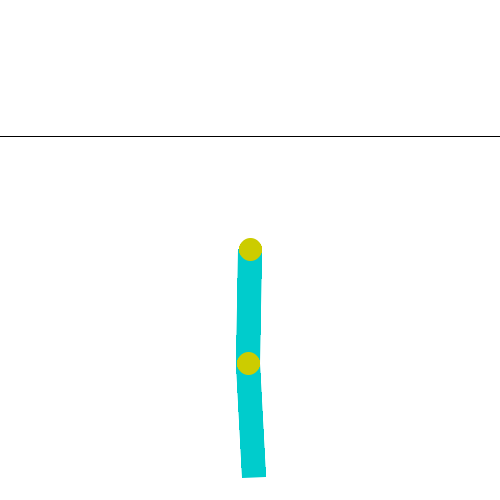

In [13]:
# raw-vs-normalized advantage diagnostic on a fresh batch from the trained nets
def adv_norm_stats(steps: int = STEPS_PER_EPOCH) -> None:
    b = RolloutBuffer(steps)
    e = make_env(); o = e.reset()[0]
    for t in range(steps):
        obs_t = torch.tensor(o, dtype=torch.float32)
        with torch.no_grad():
            a, lp = policy_net.sample_with_logprob(obs_t)
            v = critic_net(obs_t).item()
        o2, r, term, trunc, info = e.step(int(a)); b.append(obs_t, int(a), r, v, lp.item()); o = o2
        d = term or trunc
        timeout = trunc and not term; epoch_ended = t == steps - 1
        if d or epoch_ended:
            genuine = d and not timeout and not epoch_ended
            with torch.no_grad():
                last_v = 0.0 if genuine else critic_net(torch.tensor(o, dtype=torch.float32)).item()
            b.finish_trajectory(last_v); o = e.reset()[0]
    e.close()
    ob, ac, ret, adv, logp_old = b.get_data()
    nrm = normalize_advantages(adv)
    for name, x in [("raw ", adv), ("norm", nrm)]:
        x = np.asarray(x, np.float64)
        print(f"{name} adv: mean {x.mean():+6.2f}  std {x.std():6.2f}  min {x.min():7.1f}  max {x.max():6.1f}")

adv_norm_stats()

mean_ret, std_ret = evaluate(n_episodes=30)
print(f"\nV5 greedy return on {ENV_NAME}: {mean_ret:.1f} +/- {std_ret:.1f}")
print("Line it up against V0 (-421 +/- 157) ... V4 (-85 +/- 12). That's the whole story.")
record_gif("v5_baseline.gif")

---
*Series complete. If you want to keep going: swap in a harder env (`LunarLander-v3` is the classic
next step), or diff your implementation against `spinup/algos/pytorch/ppo/ppo.py` and see how few
real differences remain.*